In [248]:
import jax 
import jax.numpy as jnp
import numpy as np 
import matplotlib.pyplot as plt 

In [249]:
# parametros 
Swc = 0.1 # saturação da agua conata
Sor = 0.2 # saturação do oleo residual
krw0 = 0.5 # permeabilidade relativa da agua no ponto final
kro0 = 0.9 # permeabilidade relativa do oleo no ponto final
nw = 2.0 # exponte da fase molhante 
no = 3.0 # expoente da fase nao molhante
uw = 1.28 # viscosidade da agua
uo = 1.22 # vicosidade do oleo
phi = (0.15+0.25)/2 #porosidade media
Sw0 = 0.1

v = 0.5 #velocidade definida arbitrariamente



In [250]:
ti = 0.0 
tf = 2.0 
N = 1001

Li = 0.0
Lf = 6.0 
M = 101

t = np.linspace(ti,tf,N)
x = np.linspace(Li,Lf,M)

dt = 0.01
dx = 0.1

h = (v*dt)/(dx*phi)

maximo = 3.56903545527566
print("Critério CFL: {}".format(h*maximo))

Critério CFL: 0.8922588638189147


In [251]:
def Krw(Sw): 
    return krw0 * ((Sw - Swc) /(1 - Swc - Sor))**nw

def Kro(Sw):
    return kro0 * (1 - ((Sw - Swc)/(1 - Swc - Sor)))**no

def fw(Sw): 
    lmbd_w = Krw(Sw)/uw # mobilidade da agua
    lmbd_o = Kro(Sw)/uo # mobilidade do oleo

    return lmbd_w/(lmbd_w + lmbd_o)






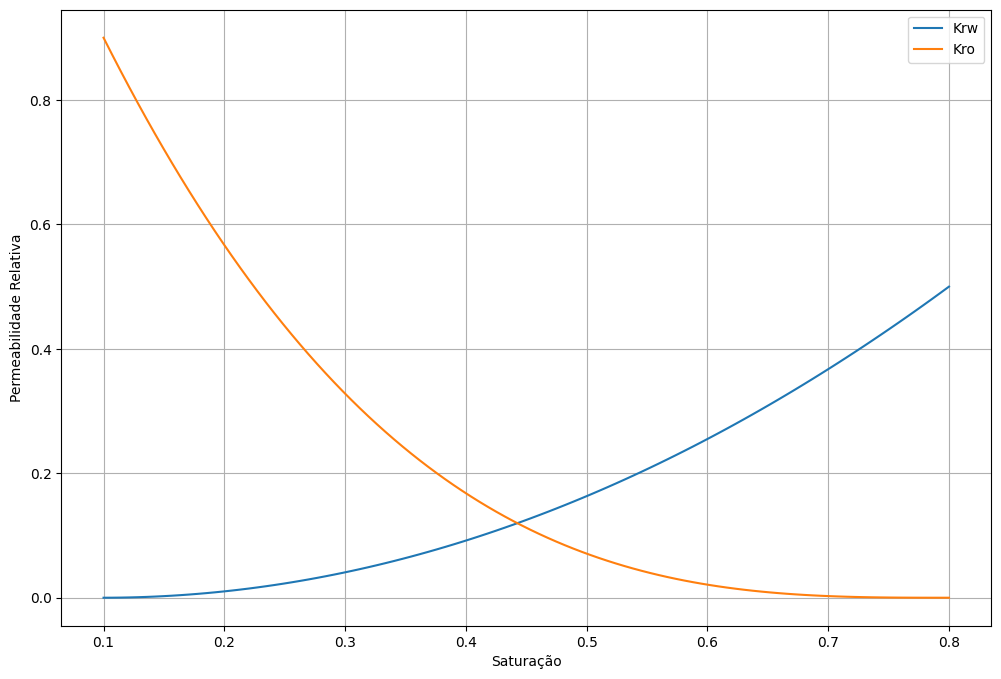

In [252]:
perm_rel_o = np.zeros(M)
perm_rel_w = np.zeros(M)

Sw_plot = np.linspace(Swc, 1-Sor,100)
perm_rel_w = Krw(Sw_plot)
perm_rel_o = Kro(Sw_plot)

plt.figure(figsize=(12,8))
plt.plot(Sw_plot,perm_rel_w, label = 'Krw')
plt.plot(Sw_plot,perm_rel_o,label = 'Kro')
plt.xlabel("Saturação")
plt.ylabel("Permeabilidade Relativa")
plt.grid(True)
plt.legend()
plt.show()

In [253]:
# nao trabalhar com matrizes
# criar uma lista com o historico de Sw em algum tempo desejado para plotar posteriormente 
Sw = np.zeros(M)
Sw[:] = Sw0

plot_values = [0.0,int(N/4),int(N/2),int(3*N/4),N-1]
Sw_historico = []
Sw_historico.append(Sw.copy()) 

for i in range(N):
    Sw[1:] = Sw[1:] - (h*(fw(Sw[1:])-fw(Sw[:-1])))
    Sw[0] = 1 - Sw0
    if i == 0:
        continue
    elif i in plot_values:
        Sw_historico.append(Sw.copy())



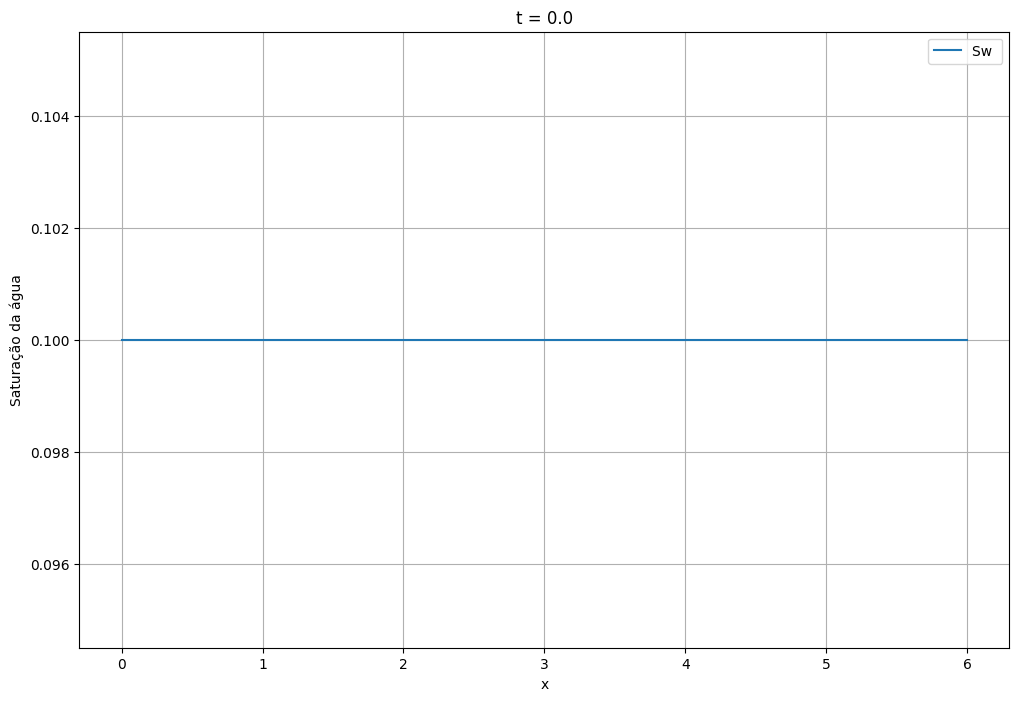

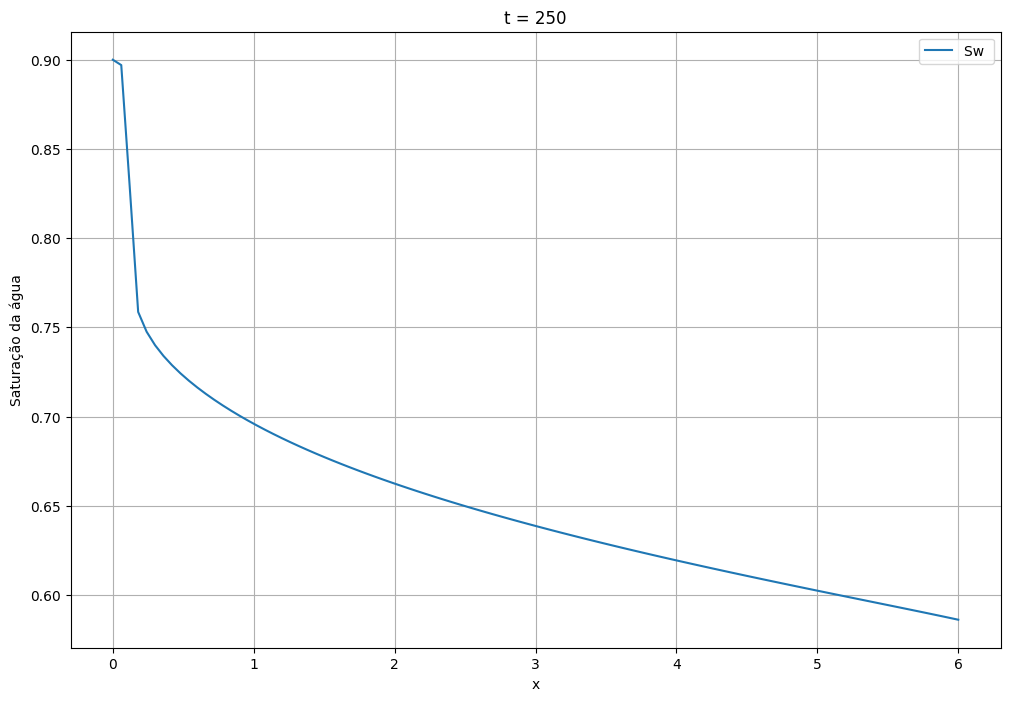

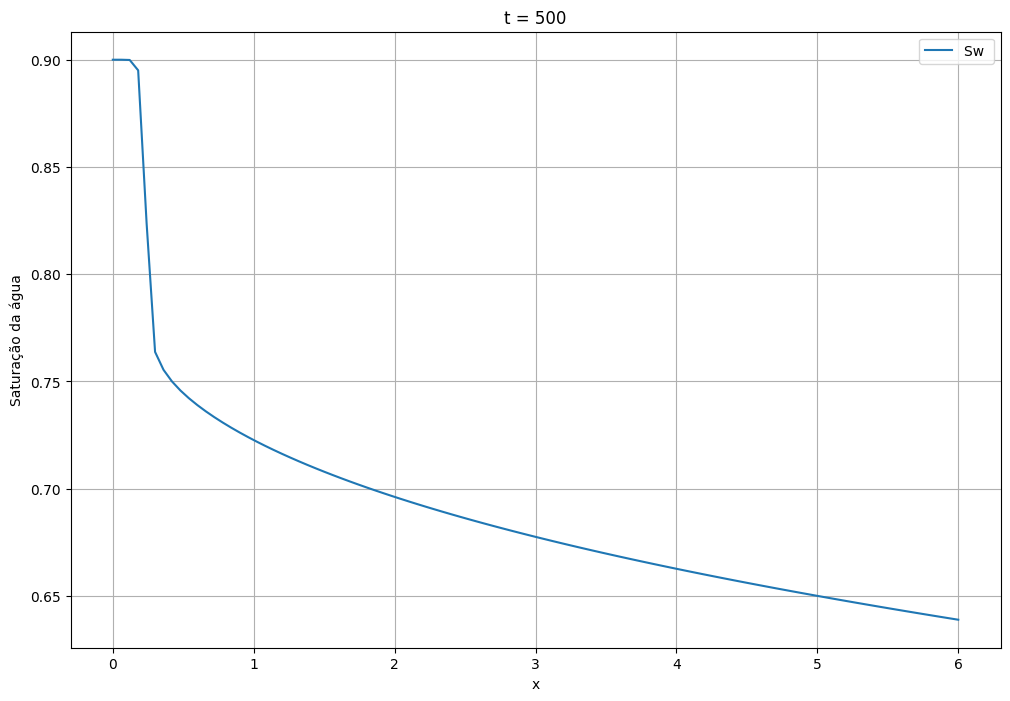

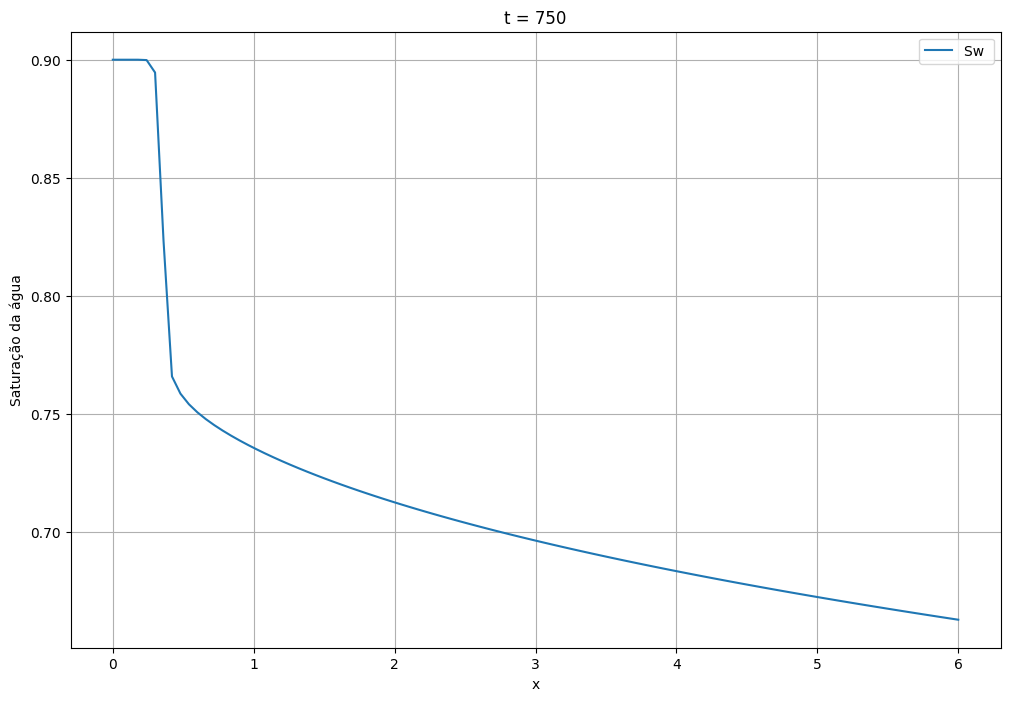

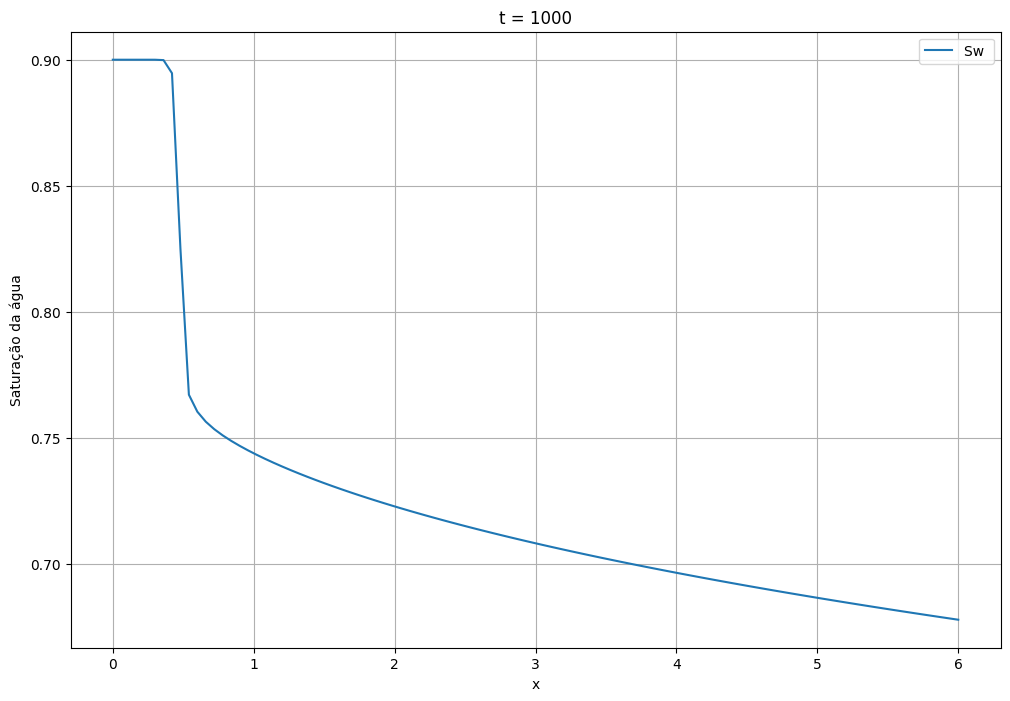

In [254]:


for i in range(len(Sw_historico)):
    
    plt.figure(figsize=(12,8))
    plt.plot(x,Sw_historico[i],label = 'Sw ')
    plt.xlabel("x")
    plt.ylabel("Saturação da água")
    plt.title("t = {}".format(plot_values[i]))
    plt.grid(True)
    plt.legend()
    plt.show()
